In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from IPython.display import clear_output
from matplotlib import cm


In [2]:
# Load iniital data
def load_data():
    folder1 = Path(r'C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data')
    folder2 = Path(r'function_2')
    file_path_inputs = folder1 / folder2 / "initial_inputs.npy"
    file_path_outputs = folder1 / folder2 / "initial_outputs.npy"
    # print(file_path_inputs)
    X = np.load(file_path_inputs)
    Y = np.load(file_path_outputs)
    return X,Y

X,Y = load_data()

In [3]:
print('X.shape', X.shape)
print('X col1 min',np.min(X[:, 0]), 'max',np.max(X[:, 0]))
print('X col2 min',np.min(X[:, 1]), 'max',np.max(X[:, 1]))
print('Y.shape', Y.shape)
print("Min Y =",min(Y),"Max Y =",max(Y))

X.shape (10, 2)
X col1 min 0.14269907423594608 max 0.8777909889953304
X col2 min 0.028697719822277867 max 0.9265641975455574
Y.shape (10,)
Min Y = -0.06562362443733738 Max Y = 0.6112052157614438


In [4]:
print("X",X)
print("y",Y)

X [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]
y [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]


In [5]:
def heat_scatter(X,Y):
    plt.figure(figsize=(10, 7))
    
    # We use SymLogNorm because your data has negatives and extremely small positives
    norm = colors.SymLogNorm(linthresh=1e-20, linscale=1, vmin=Y.min(), vmax=Y.max())
    
    scatter = plt.scatter(X[:, 0], X[:, 1], c=Y, s=200, edgecolors='black', 
                          cmap='RdYlBu', norm=norm)
    
    # Add labels for each point's order (1 to 10)
    for i, txt in enumerate(range(1, len(Y) + 1)):
        plt.annotate(txt, (X[i, 0]+0.02, X[i, 1]+0.02))
    plt.colorbar(scatter, label='Y value (Symmetric Log Scale)')
    plt.xlabel('Input Feature 1 ($x_1$)')
    plt.ylabel('Input Feature 2 ($x_2$)')
    plt.title('Contest Data: Sample Locations and Observations')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

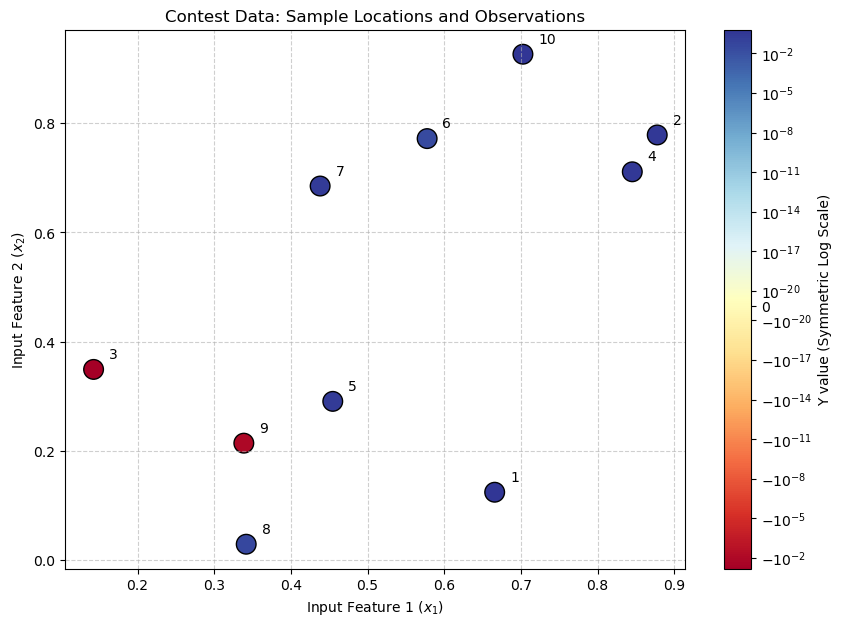

In [6]:
heat_scatter(X,Y)

In [7]:
# def plot3Dprediction(X,Y,model):
#     import numpy as np
#     import matplotlib.pyplot as plt
#     from matplotlib import cm
    
#     # 1. Determine the bounds of your loaded data for the grid
#     # 2. Create a dense grid for predictions
#     # We use 50x50 points to create a smooth surface
#     x1_linspace = np.linspace(0, 1, 50)
#     x2_linspace = np.linspace(0, 1, 50)
#     X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
    
#     # Flatten the grid to feed into the model
#     x_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
    
#     # 3. Predict using your fitted model
#     y_pred, std = model.predict(x_test, return_std=True)
    
#     # Reshape predictions back into the grid shape for plotting
#     Z_mean = y_pred.reshape(X1_grid.shape)
#     Z_std = std.reshape(X1_grid.shape)
    
#     # 4. Create the Visualization
#     fig = plt.figure(figsize=(16, 6))
    
#     # --- Subplot 1: 3D Surface of Predicted Mean ---
#     ax1 = fig.add_subplot(121, projection='3d')
#     surf = ax1.plot_surface(X1_grid, X2_grid, Z_mean, cmap='viridis', alpha=0.8, edgecolor='none')
#     ax1.scatter(X[:, 0], X[:, 1], Y, color='red', marker='x', s=50, label='Actual Data')
#     ax1.set_title('GP Predicted Mean Surface')
#     ax1.set_zlabel('Output Y')
#     fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
    
#     # --- Subplot 2: Heatmap of Uncertainty (Std Dev) ---
#     ax2 = fig.add_subplot(122)
#     contour = ax2.contourf(X1_grid, X2_grid, Z_std, levels=20, cmap='YlOrRd')
#     # contour = ax2.contourf(X1_grid, X2_grid, Z_mean, levels=20, cmap='YlOrRd')
#     ax2.scatter(X[:, 0], X[:, 1], c='black', marker='+', alpha=0.5)
#     ax2.set_title('Model Uncertainty (Std Dev)')
#     ax2.set_xlabel('Input Feature 1')
#     ax2.set_ylabel('Input Feature 2')
#     fig.colorbar(contour, ax=ax2, label='Standard Deviation')
    
#     plt.tight_layout()
#     plt.show()

In [8]:
def plot3Dprediction2(X,Y, y_pred, std, X1_grid, X2_grid):
    # Reshape predictions back into the grid shape for plotting
    Z_mean = y_pred.reshape(X1_grid.shape)
    Z_std = std.reshape(X1_grid.shape)
    
    # 4. Create the Visualization
    fig = plt.figure(figsize=(16, 6))
    
    # --- Subplot 1: 3D Surface of Predicted Mean ---
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(X1_grid, X2_grid, Z_mean, cmap='viridis', alpha=0.8, edgecolor='none')
    ax1.scatter(X[:, 0], X[:, 1], Y, color='red', marker='x', s=50, label='Actual Data')
    ax1.set_title('GP Predicted Mean Surface')
    ax1.set_zlabel('Output Y')
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
    
    # --- Subplot 2: Heatmap of Uncertainty (Std Dev) ---
    ax2 = fig.add_subplot(122)
    contour = ax2.contourf(X1_grid, X2_grid, Z_std, levels=20, cmap='YlOrRd')
    # contour = ax2.contourf(X1_grid, X2_grid, Z_mean, levels=20, cmap='YlOrRd')
    ax2.scatter(X[:, 0], X[:, 1], c='black', marker='+', alpha=0.5)
    ax2.set_title('Model Uncertainty (Std Dev)')
    ax2.set_xlabel('Input Feature 1')
    ax2.set_ylabel('Input Feature 2')
    fig.colorbar(contour, ax=ax2, label='Standard Deviation')
    
    plt.tight_layout()
    plt.show()

## Matern Kernel

In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
X,Y = load_data()
# 1. Define the Kernel
# Matern is the gold standard for black-box optimization.
# nu=2.5 provides a good balance between smoothness and flexibility.
Matern_kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5, 0.5], 
                                     length_scale_bounds=(1e-3, 1e5), nu=2.5
                                     ) + WhiteKernel(noise_level=1e-10, 
                                    noise_level_bounds=(1e-18, 1e-2))
# 2. Setup the Regressor
model = GaussianProcessRegressor(
    kernel=Matern_kernel,
    alpha=0,               # Let WhiteKernel handle the noise instead
    normalize_y=True,        # CRITICAL: This scales those tiny e-124 values so the GP can see them
    n_restarts_optimizer=20)   # Gives the optimizer 15 tries to find the best fit
# 3. Fit the model
model.fit(X, Y)
print(f"Optimized Kernel: {model.kernel_}")

Optimized Kernel: 1.06**2 * Matern(length_scale=[0.0742, 9.17e+04], nu=2.5) + WhiteKernel(noise_level=0.01)


C:\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Prediction done


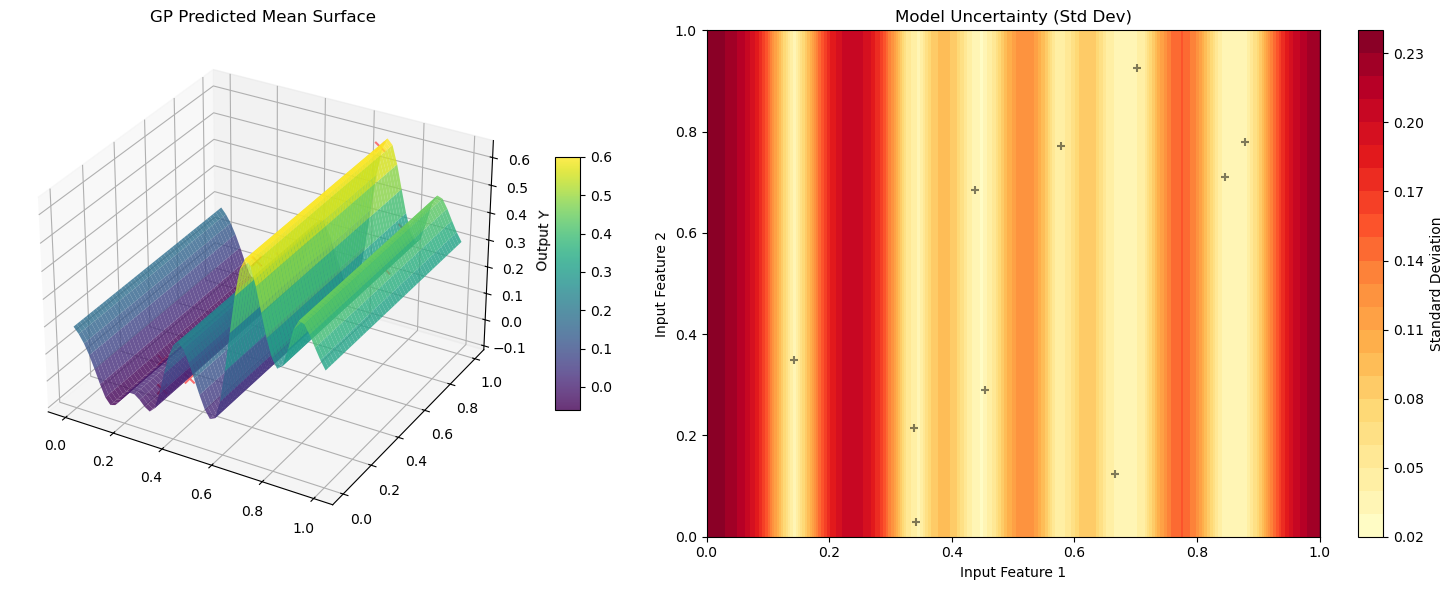

Data so far (sorted by descending observations): 
1: (x, f(x)) = ('0.67, 0.12', '5.3900e-01')
2: (x, f(x)) = ('0.88, 0.78', '4.2059e-01')
3: (x, f(x)) = ('0.14, 0.35', '-6.5624e-02')
4: (x, f(x)) = ('0.85, 0.71', '2.9399e-01')
5: (x, f(x)) = ('0.45, 0.29', '2.1496e-01')
6: (x, f(x)) = ('0.58, 0.77', '2.3106e-02')
7: (x, f(x)) = ('0.44, 0.69', '2.4462e-01')
8: (x, f(x)) = ('0.34, 0.03', '3.8749e-02')
9: (x, f(x)) = ('0.34, 0.21', '-1.3858e-02')
10: (x, f(x)) = ('0.70, 0.93', '6.1121e-01')
The GP predicts the value at [0.693878, 0.612245] will be 0.609597


In [10]:
AcquisitionFunctionBeta = 0 # 1.96
max_obs = -1

# create empty grid to feed in to the model
x1_linspace = np.linspace(0, 1, 50)
x2_linspace = np.linspace(0, 1, 50)
X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
x_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

#Number of queries in the optimisation loop
num_queries = 1
for i in range(0, num_queries):
    #Clear the outputs to keep the interface clean
    clear_output(wait = True)
    #  model = GaussianProcessRegressor(kernel=Matern_kernel, alpha=0, normalize_y=True, n_restarts_optimizer=20)
    # if i != 0:
    #     Fit the model
    #     model.fit(X,Y)
    #Calculate the mean and standard deviation and make them one-dimensional for plotting
    post_mean, post_std = model.predict(x_grid, return_std=True)
    print("Prediction done")

    plot3Dprediction2(X,Y, post_mean, post_std, X1_grid, X2_grid)
    # plot3Dprediction(X,Y,model)
    
    # DISPLAY OF X AND Y
    #Select a display format for X and Y
    X_format =  ['%.2f' % query[0] + ', %.2f' % query[1] for query in X]  # Format for 2D points
    Y_format = ['%.4e' % obs for obs in Y] #Four sig figs
    data = [(query, obs) for query, obs in zip(X_format, Y_format)]
    print('Data so far (sorted by descending observations): ')
    print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start = 1))) #Display data
    
    # _ = input('Human Input to continue')
    
    # Acquisition function (UCB)
    acquisition_function = post_mean + AcquisitionFunctionBeta * post_std
    
    # Find the index of the maximum value in the acquisition function
    best_index = np.argmax(acquisition_function)
    
    # Get the corresponding x value from the grid
    x_next = x_grid[best_index]  # This will be a 2D point
    y_predicted = post_mean[best_index]
    
    print(f"The GP predicts the value at [{x_next[0]:.6f}, {x_next[1]:.6f}] will be {y_predicted:.6f}")

    # Append data
    X = np.vstack([X, x_next])  # Use np.vstack to add a new row to X
    Y = np.append(Y, y_predicted)  # Use np.append to add a new value to Y
    
    # Sort lists according to observation values
    sorted_indices = np.argsort(-Y)  # Negative for descending order
    X = X[sorted_indices]
    Y = Y[sorted_indices]
    max_obs = max(max_obs, y_predicted)

In [149]:
print(acquisition_function.shape)
print("np.argmax(acquisition_function)", np.argmax(acquisition_function))
print("x_next",x_next)
print(post_mean[:5])

(2500,)
np.argmax(acquisition_function) 2184
x_next [0.69387755 0.87755102]
[-3.60303076e-04 -3.57746793e-04 -3.37562385e-04 -2.23774303e-04
 -8.21367320e-07]


## RBF Kernel - IGNORE

In [186]:
# # ########  IGNORE THIS 
# X,Y = load_data()
# # define the kernel, initialise the GP model, train
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF
# rbf_lengthscale = 0.1
# noise_assumption = 1e-8
# # kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
# RBFkernel = RBF(length_scale=0.1, length_scale_bounds=(1e-2, 1e5))
#                      # length_scale_bounds=(1e-2, 1e3)  = model searches for good value
# model = GaussianProcessRegressor(kernel = RBFkernel, alpha=noise_assumption, n_restarts_optimizer=25)
#                      # n_restarts_optimizer runs the optimization 10 times
# model.fit(X, Y)
# print(f"Optimized Kernel: {model.kernel_}")

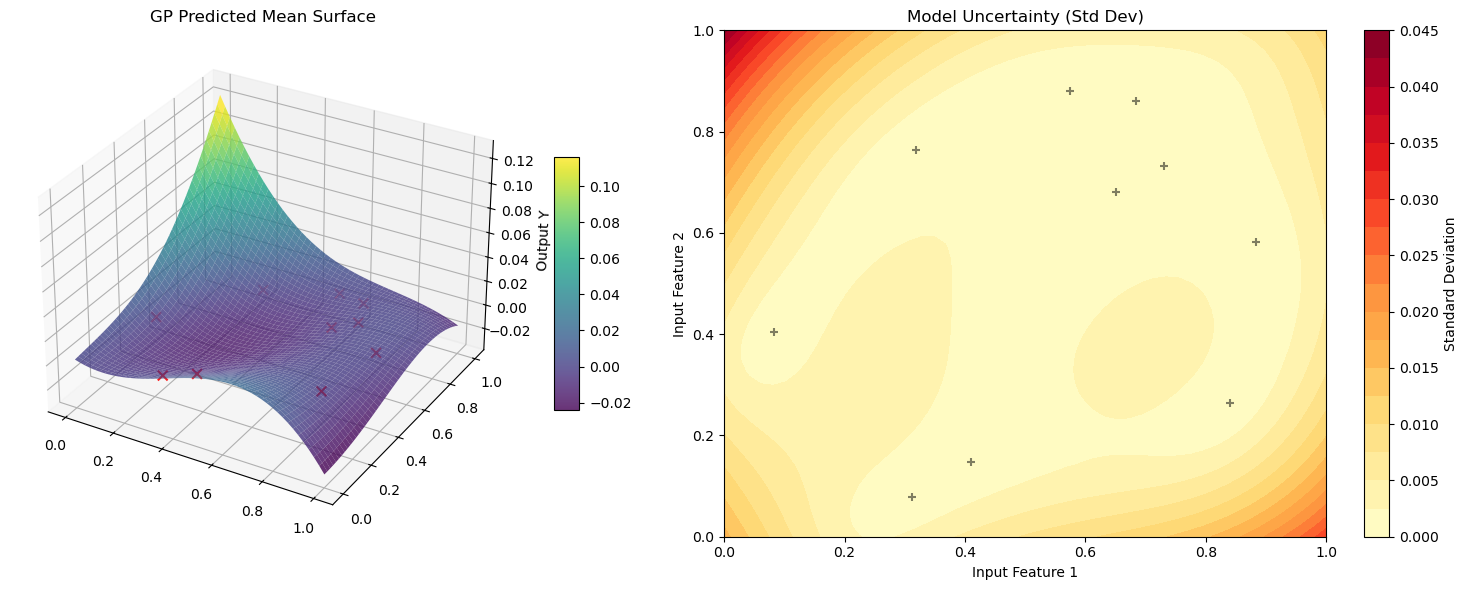

TypeError: only length-1 arrays can be converted to Python scalars

In [61]:
# AcquisitionFunctionBeta = 1.96
# max_obs = -1

# # create empty grid to feed in to the model
# x1_linspace = np.linspace(0, 1, 50)
# x2_linspace = np.linspace(0, 1, 50)
# X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
# # Flatten the grid to feed into the model
# x_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

# #Number of queries in the optimisation loop
# num_queries = 1

# for i in range(0, num_queries):
#     clear_output(wait = True)
#     # model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)
#     # model = GaussianProcessRegressor(kernel=RBFkernel,alpha=0, normalize_y=True, n_restarts_optimizer=20)
#     #Fit the model
#     # model.fit(X,Y)
#     #Calculate the mean and standard deviation and make them one-dimensional for plotting
#     post_mean, post_std = model.predict(x_grid, return_std=True)
#     # post_mean, post_std = post_mean.squeeze(), post_std.squeeze()
    
#     #Initialise plots
#     plot3Dprediction2(X,Y,model)
    
#     # DISPLAY OF X AND Y
#     #Select a display format for X and Y
#     X_format = ['%.2f' % query for query in X] #Two sig figs
#     Y_format = ['%.4f' % obs for obs in Y] #Four sig figs
#     data = [(query, obs) for query, obs in zip(X_format, Y_format)]
#     print('Data so far (sorted by descending observations): ')
#     print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start = 1))) #Display data
    
#     #Initialise x
#     x = -1
#     # _ = input('Input anything to see the next chosen point') #You are using this to allow the user to change plots
    
#     acquisition_function = post_mean + AcquisitionFunctionBeta * post_std
    
#     grid = x_grid.squeeze()
#     x = grid[np.argmax(acquisition_function)]         #  use the acquisition function
#     print("argmax from acquisition_function =",x)

#     best_index = np.argmax(acquisition_function)
#     x_next = grid[best_index]
#     y_predicted = post_mean[best_index]   
#     print(f"The GP predicts the value at {x_next:.4f} will be {y_predicted:.4f}")

#     #Append data, calculate function and sort lists according to observation values
#     X.append(x)
#     y = y_predicted
#     Y.append(y)
#     X = [x for _, x in sorted(zip(Y, X), reverse = True)]
#     Y.sort(reverse = True)
#     max_obs = max(max_obs, y)


## Misc

In [5]:
folder1 = Path(r'C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data')
folder2 = Path(r'function_2')
file_path_inputs = folder1 / folder2 / "initial_inputs.npy"
print(file_path_inputs)

C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data\function_2\initial_inputs.npy


In [103]:
num = 1

for i in range(0, num):
    print("count")

count
